# **Climate Academy Encyclopedia & Knowledge Graph Generation**


---


  This notebook demonstrates a workflow for generating a **climate Academy encyclopedia and knowledge graph** from the *Climate Academy Book* using the **SemanticClimate Toolkit**.

### **Workflow Overview**
1. Convert the Climate Academy PDF into plain text.
2. Extract important climate-related keywords.
3. Use these keywords to generate encyclopedia entries from wikipedia.
4. Build a knowledge graph linking the concepts in Encyclopedia.

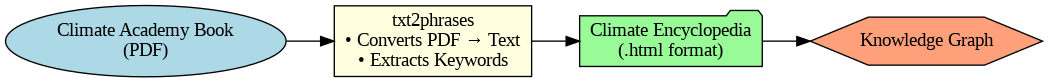
### **Tools Used**
- **txt2phrases** – Extracts keywords and converts documents to text
- **SemanticClimate Encyclopedia Toolkit** – Generates encyclopedia pages


---
---


The final outputs include:
- A **Climate Encyclopedia (HTML)**
- A **Knowledge Graph of Climate Concepts**


## **Step1-Installing Required Tool: txt2phrases**

We install **txt2phrases**, a Natural Language Processing (NLP) tool used to extract meaningful phrases and keywords from text documents.

### What this tool does
- Converts documents (PDF → text)
- Extracts important keywords
- Identifies domain-specific phrases

This tool helps us identify **important climate science concepts** from the Climate Academy chapter.

In [ ]:
!pip install txt2phrases

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 13.2 MB/s eta 0:00:00


## **Step2- Convert pdf to text- using txt2phrases**


**Command:**

      txt2phrases pdf2txt -i ClimateAcademy_Book.pdf -o /content/

**Parameters:**
- `pdf2txt` : converts PDF into plain text
- `-i` : input PDF file
- `-o` : output directory for generated text

**Purpose:**
Extract machine-readable text from the Climate Academy PDF.



In [ ]:
!txt2phrases pdf2txt -i /content/ClimateAcademy_Book.pdf -o /content/

Converted /content/ClimateAcademy_Book.pdf to TXT


## **Step3-Extract keywords using txt2phrases**
**Purpose:** Identify important climate-related concepts from the text.

**Command:**

        txt2phrases keyphrases -i ClimateAcademy_Book.txt -o keywords.csv -n 100

**Parameters:**
- `keyphrases` : extracts important phrases
- `-i` : input text file
- `-o` : output file for extracted keywords
- `-n` : number of phrases to extract

**Output**
 -  csv of keywords
 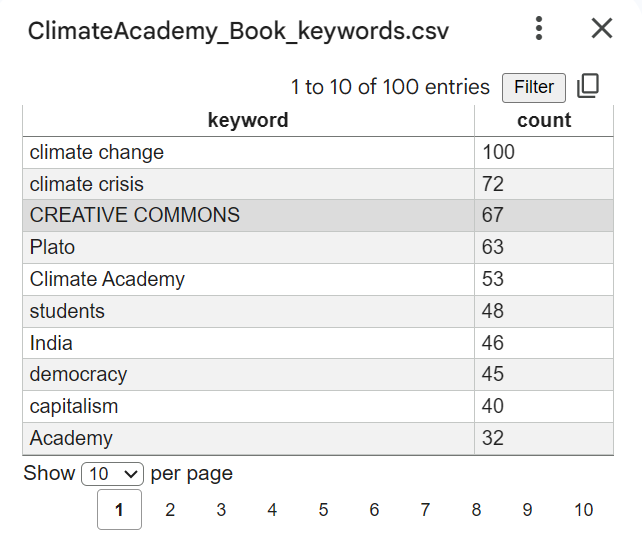

In [ ]:
!txt2phrases keyphrases -i /content/ClimateAcademy_Book.txt -o /content/climate_academy_keywords.csv -n 100

config.json: 100% 855/855 [00:00<00:00, 3.04MB/s]
pytorch_model.bin: 100% 1.42G/1.42G [00:24<00:00, 58.8MB/s]
Loading weights: 100% 391/391 [00:00<00:00, 786.22it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]
RobertaForTokenClassification LOAD REPORT from: ml6team/keyphrase-extraction-kbir-inspec
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
model.safetensors:   0% 0.00/1.42G [00:00<?, ?B/s]
tokenizer_config.json: 1.16kB [00:00, 1.79MB/s]
model.safetensors:   0% 0.00/1.42G [00:01<?, ?B/s]
vocab.json: 798kB [00:00, 22.6MB/s]

merges.txt: 456kB [00:00, 73.3MB/s]
model.safetensors:   5% 68.7M/1.42G [00:02<00:16, 83.9MB/s]
tokenizer.json: 0.00B [00:00, ?B/s]
tokenizer.json: 2.11MB [00:00, 13.1MB/s]

special_tokens_map.json: 100% 772/772 [00:00

# **Step4-Clone Encyclopedia Repository**
Download scripts required for encyclopedia generation.

Command:
git clone -b pmr202601 https://github.com/semanticClimate/encyclopedia.git

Parameters:
- `clone` : downloads repository
- `-b pmr202601` : specifies branch to clone
- repository URL : source GitHub repository

In [ ]:
!git clone -b pmr202601 https://github.com/semanticClimate/encyclopedia.git

Cloning into 'encyclopedia'...
remote: Enumerating objects: 2541, done.
remote: Counting objects: 100% (383/383), done.
remote: Compressing objects: 100% (264/264), done.
remote: Total 2541 (delta 184), reused 267 (delta 119), pack-reused 2158 (from 3)
Receiving objects: 100% (2541/2541), 421.79 MiB | 14.95 MiB/s, done.
Resolving deltas: 100% (803/803), done.
Updating files: 100% (617/617), done.


## **Step5- Move to Repository Folder**

**Command:**

      %cd /content/encyclopedia/

Explanation:
- `%cd` : Jupyter magic command to change working directory
- `/content/encyclopedia/` : cloned repository location

In [ ]:
%cd /content/encyclopedia/

/content/encyclopedia


## **Step6- Install the Repository as a Python Package**

We install the repository (encyclopedia) as a **Python package in editable mode**.

 **What this does**
- Installs the toolkit locally
- Allows the scripts in the repository to be executed directly

---


 **Command Used**
        
        `pip install -e .`

**Parameters:**
- `install` : installs package
- `-e` : editable installation
- `.` : current directory



---



In [ ]:
!pip install -e.

Obtaining file:///content/encyclopedia
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 24.9 MB/s eta 0:00:0

## **Step7- Create an Encyclopedia**

Using the extracted keywords from Climate Academy Book, we now generate an **encyclopedia** with wikipedia descriptions and images.

---

* **Command:**

      python create_encyclopedia_from_wordlist.py --content keylist.txt --add-images --skip-deletion --output climate_encyclopedia.html

**Parameters:**
- `--content` : input keyword list
- `--add-images` : include images
- `--skip-deletion` : retain existing entries
- `--output` : output HTML file


In [ ]:
!python Examples/create_encyclopedia_from_phraselist.py \
--input /content/climate_academy_keywords.csv/ClimateAcademy_Book_keywords.csv \
--output /content/encyclopedia_ClimateAcademy.html \
--add-wikipedia \
--add-images \
--batch-size 10

<root id="root">
        <section>
            <item id="item1"/>
            <item/>
            <item/>
        </section>
        <section>
            <item/>
            <item/>
        </section>
    </root>

Reading phrases from: /content/climate_academy_keywords.csv/ClimateAcademy_Book_keywords.csv

✓ Loaded 100 phrases with counts from ClimateAcademy_Book_keywords.csv

Creating encyclopedia 'Encyclopedia'...


Creating encyclopedia 'Encyclopedia' from 100 terms...

Step 1: Creating dictionary from terms...
INFO ami_dict.py:972:duplicate term: Tipping Points ignored 
INFO:amilib.ami_dict:duplicate term: Tipping Points ignored 
INFO ami_dict.py:972:duplicate term: Climate Anxiety ignored 
INFO:amilib.ami_dict:duplicate term: Climate Anxiety ignored 
INFO ami_dict.py:972:duplicate term: History ignored 
INFO:amilib.ami_dict:duplicate term: History ignored 
INFO ami_dict.py:972:duplicate term: Capitalism ignored 
INFO:amilib.ami_dict:duplicate term: Capitalism ignored 
INFO ami_di

## **Step8- Building the Climate Academy Knowledge Graph**
The final step is to construct a **knowledge graph** from the generated encyclopedia.


---



* **Command:**

      python create_encyclopedia_from_wordlist.py --content keylist.txt --add-images --skip-deletion --output climate_encyclopedia.html

**Parameters:**
- `--content` : input keyword list
- `--add-images` : include images
- `--skip-deletion` : retain existing entries
- `--output` : output HTML file

---
### **Output**
- A **knowledge graph** representing relationships between key terms.

- This graph can later be visualized or analyzed to understand **concept relationships in Climate Academy Book**.


In [ ]:
!python Examples/create_knowledge_graph.py --input /content/encyclopedia_ClimateAcademy.html --output /content/results/knowledge_graph_climateAcademy.graphml --format graphml --include-wikipedia --include-wikidata --verbose

<root id="root">
        <section>
            <item id="item1"/>
            <item/>
            <item/>
        </section>
        <section>
            <item/>
            <item/>
        </section>
    </root>
Loading encyclopedia from /content/encyclopedia_ClimateAcademy.html...
✓ Loaded 91 entries
Building knowledge graph...
  - Wikipedia links: True
  - Wikidata relationships: True
✓ Graph created: 874 nodes, 2703 edges
Exporting graph to temp/knowledge_graphs/encyclopedia_ClimateAcademy/encyclopedia_ClimateAcademy.graphml (graphml format)...
✓ Graph exported successfully to temp/knowledge_graphs/encyclopedia_ClimateAcademy/encyclopedia_ClimateAcademy.graphml
  Format: graphml
  Nodes: 874
  Edges: 2703

  Edge types:
    shared_value: 1639
    wikipedia_link: 652
    P527: 145
    P31: 142
    P279: 87
    P361: 31
    P2670: 7
